# Week 10–11 : Fourier Series와 주파수 분석 실습

**신호 및 시스템 (Signals and Systems)**

이번 실습에서는 Fourier Series의 핵심 개념을 바탕으로, **STFT(Short-Time Fourier Transform)를 이용한 스펙트로그램(Spectrogram) 생성**과 **주파수별 분해를 통한 신호 분석** 예시를 직접 구현해 봅니다.

### 학습 목표
1. **Fourier Series 계수 계산** — 주기 신호를 고조파(harmonic) 성분으로 분해한다.
2. **주파수별 분해 및 복원** — 각 고조파 성분을 시각화하고, 합성하여 원 신호를 복원한다.
3. **Gibbs 현상** — Fourier Series의 수렴과 불연속점에서의 오버슈트를 확인한다.
4. **STFT와 스펙트로그램** — 시간에 따라 주파수 구성이 변하는 신호를 분석한다.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt #그래프 시각화
from scipy.signal import stft, spectrogram # STFT 연산 및 스펙트로그램 생성
import librosa  # 직접 녹음한 음성 파일을 파이썬으로 불러오고 음성 처리를 할 때 가장 널리 쓰이는 라이브러리
import librosa.display

# 그래프를 그릴 때 한글이 깨지지 않게 하고 크기를 설정하는 부분
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

---
## 1. Fourier Series 계수 계산 및 주파수별 분해

### 이론 요약

주기 $T$, 기본 주파수 $\omega_0 = \frac{2\pi}{T}$인 주기 신호 $x(t)$는 다음과 같이 **Fourier Series**로 표현됩니다:

$$x(t) = \sum_{k=-\infty}^{+\infty} a_k \, e^{j k \omega_0 t}$$

여기서 Fourier Series 계수 $a_k$는:

$$a_k = \frac{1}{T} \int_{T} x(t) \, e^{-j k \omega_0 t} \, dt$$

실수 주기 신호의 경우, trigonometric form으로 다시 쓸 수 있습니다:

$$x(t) = a_0 + 2 \sum_{k=1}^{\infty} A_k \cos(k\omega_0 t + \theta_k)$$

여기서 $a_k = A_k e^{j\theta_k}$ (polar form) 입니다.

> **핵심:** LTI 시스템에서 $e^{j\omega t}$가 입력되면 출력도 $H(j\omega) e^{j\omega t}$로, **주파수는 변하지 않고** 크기와 위상만 변합니다. 따라서 신호를 주파수별로 분리하면, 각각에 대한 시스템 출력을 구하여 전체 출력을 합으로 나타낼 수 있습니다.

### 예제 1-1: 사각파(Square Wave)의 Fourier Series 분해

주기 $T$, 폭 $2T_1$인 사각파의 Fourier 계수:

$$a_0 = \frac{2T_1}{T}, \quad a_k = \frac{\sin(k \omega_0 T_1)}{k\pi} \quad (k \neq 0)$$

특히 $T = 4T_1$ 인 경우:

$$a_k = \frac{\sin(k\pi/2)}{k\pi}$$

각 고조파 성분을 개별적으로 시각화하고, 이를 합성하여 원래 신호를 복원해 봅시다.

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family ['Apple SD Gothic Neo'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Go

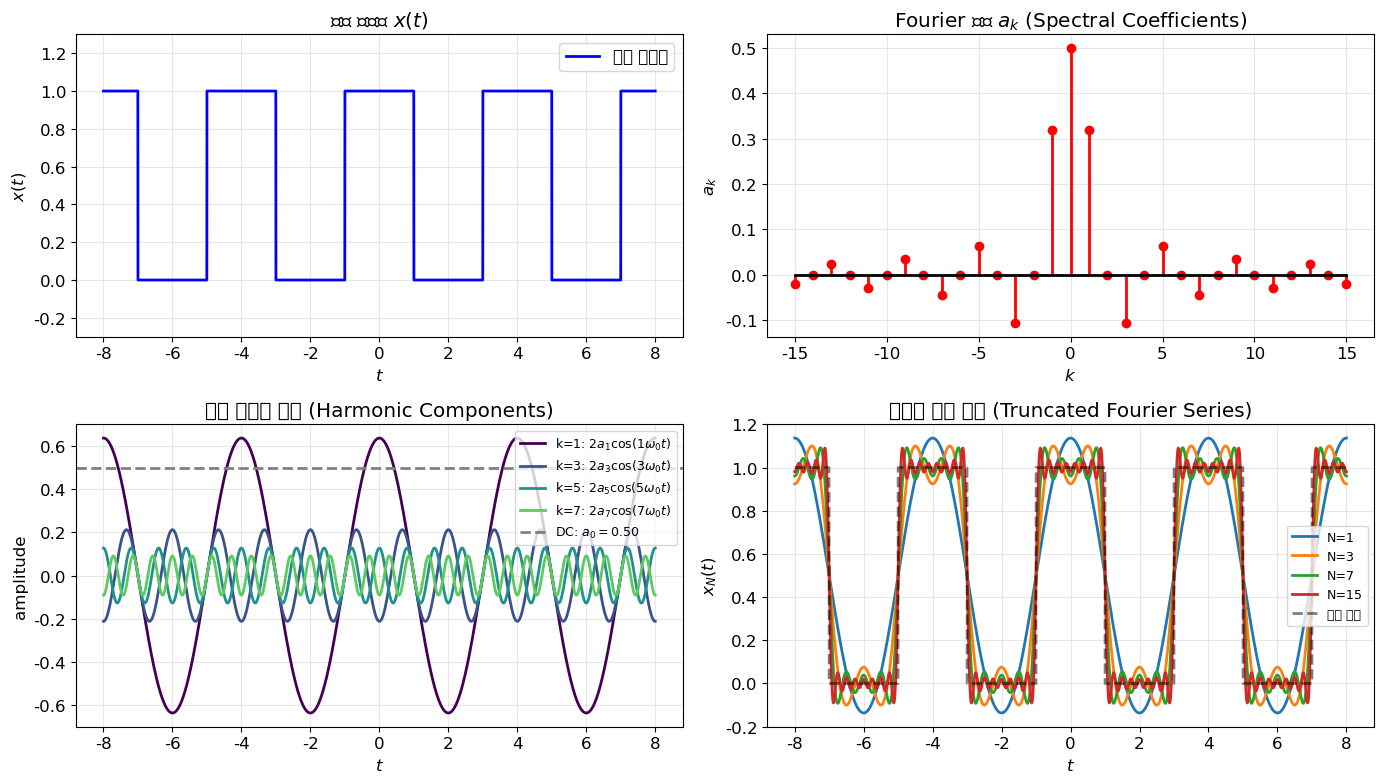

In [2]:
###===========================================================================
# 사각파의 Fourier 계수 계산 및 시각화
T = 4.0
T1 = T / 4
omega0 = 2 * np.pi / T
t = np.linspace(-2 * T, 2 * T, 4000) # -4부터 4까지 4000개의 점을 균등하게 생성

x_square = np.zeros_like(t) 
t_mod = np.mod(t + T / 2, T) - T / 2
x_square[np.abs(t_mod) <= T1] = 1.0

###===========================================================================

def square_wave_ak(k, T, T1):
    """사각파의 Fourier 계수 a_k 계산"""
    if k == 0:
        return 2 * T1 / T
    else:
        return np.sin(k * omega0 * T1) / (k * np.pi)

# 몇 번째 고조파(High harmonics)까지 볼지 정하기:15
N_harmonics = 15
# 0~15까지의 고조파에 대한 a_k 계산
a_k = np.array([square_wave_ak(k, T, T1) for k in range(N_harmonics + 1)])


###===========================================================================
# 그림 생성
# 사각파 그림
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t, x_square, 'b-', label='원래 사각파')
axes[0, 0].set_title('원래 사각파 $x(t)$')
axes[0, 0].set_xlabel('$t$')
axes[0, 0].set_ylabel('$x(t)$')
axes[0, 0].set_ylim(-0.3, 1.3) # y축 범위
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
###===========================================================================
# Fourier 계수 스펙트럼
k_vals = np.arange(-N_harmonics, N_harmonics + 1) # -15부터 15까지의 k값 생성
a_k_full = np.array([square_wave_ak(abs(k), T, T1) for k in k_vals]) # -15~15 Fourier 계수 계산, even function이므로 절댓값 사용
axes[0, 1].stem(k_vals, a_k_full, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[0, 1].set_title('Fourier 계수 $a_k$ (Spectral Coefficients)')
axes[0, 1].set_xlabel('$k$')
axes[0, 1].set_ylabel('$a_k$')
axes[0, 1].grid(True, alpha=0.3)
###===========================================================================
# 개별 고조파 성분과 누적 합성
colors = plt.cm.viridis(np.linspace(0, 1, 5))
for idx, k in enumerate([1, 3, 5, 7]): # 1,3,5,7번째 고조파 성분을 시각화
    component = 2 * a_k[k] * np.cos(k * omega0 * t) # 양의 주파수 +k와 음의 주파수 -k가 합쳐지면 cosine 형태로 나타남
    axes[1, 0].plot(t, component, color=colors[idx], label=f'k={k}: $2a_{{{k}}}\\cos({k}\\omega_0 t)$')

dc = a_k[0] * np.ones_like(t) # DC Component
axes[1, 0].axhline(y=a_k[0], color='gray', linestyle='--', label=f'DC: $a_0 = {a_k[0]:.2f}$') # DC 성분을 수평선으로 표시
axes[1, 0].set_title('개별 고조파 성분 (Harmonic Components)')
axes[1, 0].set_xlabel('$t$')
axes[1, 0].set_ylabel('amplitude')
axes[1, 0].legend(fontsize=9, loc='upper right')
axes[1, 0].grid(True, alpha=0.3)
###===========================================================================
# 고조파를 더해서 사각파 근사하기
for N in [1, 3, 7, 15]: # first harmonic, 3,5,7harmoninc 사용
    x_approx = a_k[0] * np.ones_like(t)
    for k in range(1, N + 1):
        x_approx += 2 * square_wave_ak(k, T, T1) * np.cos(k * omega0 * t)
    axes[1, 1].plot(t, x_approx, label=f'N={N}')

axes[1, 1].plot(t, x_square, 'k--', alpha=0.5, label='원래 신호')
axes[1, 1].set_title('고조파 누적 합성 (Truncated Fourier Series)')
axes[1, 1].set_xlabel('$t$')
axes[1, 1].set_ylabel('$x_N(t)$')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 예제 1-2: 복합 주기 신호의 주파수별 분해

수업에서 다룬 예시처럼, 여러 주파수 성분이 합쳐진 신호를 분해해 봅시다:

$$x(t) = 1 + \frac{1}{2}\cos(2\pi t) + \cos(4\pi t) + \frac{2}{3}\cos(6\pi t)$$

이 신호의 기본 주파수(Fundamental frequency)는 $2\pi$이며, 주기는 1초입니다.

- DC 성분: $a_0 = 1$
- 1차 고조파: $a_1 = a_{-1} = 1/4$
- 2차 고조파: $a_2 = a_{-2} = 1/2$
- 3차 고조파: $a_3 = a_{-3} = 1/3$

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
Font 'default' does not have a glyph for '\uc131' [U+c131], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubd84' [U+bd84], substituting with a d

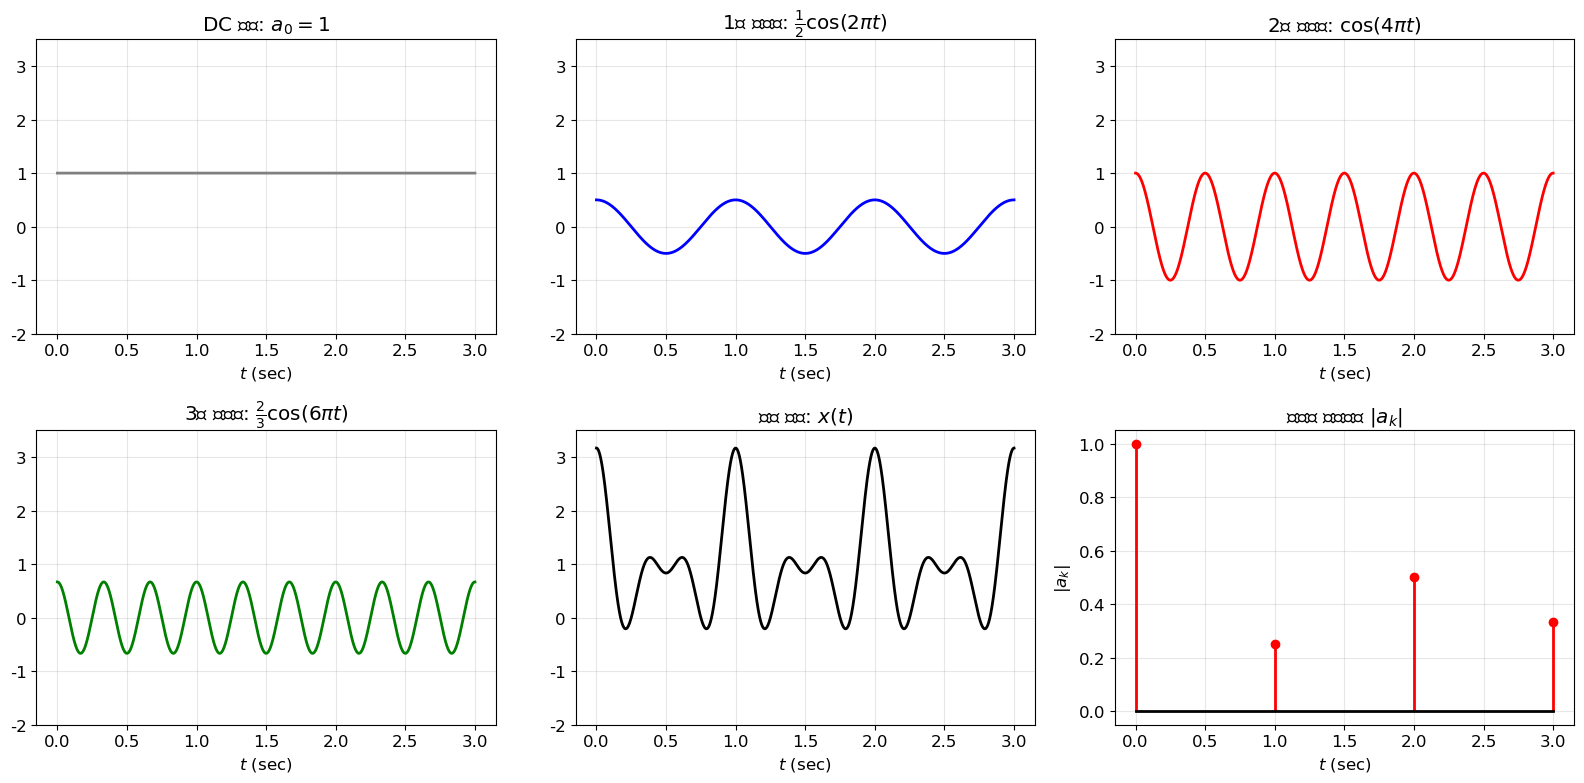

각 고조파를 분리하면, LTI 시스템의 출력을 쉽게 구할 수 있습니다!
입력: x(t) = Σ a_k e^{jkω₀t}  →  출력: y(t) = Σ a_k H(jkω₀) e^{jkω₀t}


In [3]:
t = np.linspace(0, 3, 3000) # 0부터 3초까지 3000개의 점을 균등하게 생성 (샘플링 주파수 1000Hz로 가정)

dc = np.ones_like(t) # DC Component
h1 = 0.5 * np.cos(2 * np.pi * t) # first harmonic
h2 = 1.0 * np.cos(4 * np.pi * t) # second harmonic
h3 = (2 / 3) * np.cos(6 * np.pi * t) # third harmonic 
x_combined = dc + h1 + h2 + h3

###===========================================================================
# 그래프 시각화

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(t, dc, 'gray')
axes[0, 0].set_title('DC 성분: $a_0 = 1$')
axes[0, 0].set_ylim(-2, 3.5)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t, h1, 'b')
axes[0, 1].set_title('1차 고조파: $\\frac{1}{2}\\cos(2\\pi t)$')
axes[0, 1].set_ylim(-2, 3.5)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(t, h2, 'r')
axes[0, 2].set_title('2차 고조파: $\\cos(4\\pi t)$')
axes[0, 2].set_ylim(-2, 3.5)
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(t, h3, 'g')
axes[1, 0].set_title('3차 고조파: $\\frac{2}{3}\\cos(6\\pi t)$')
axes[1, 0].set_ylim(-2, 3.5)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t, x_combined, 'k', linewidth=2)
axes[1, 1].set_title('합성 신호: $x(t)$')
axes[1, 1].set_ylim(-2, 3.5)
axes[1, 1].grid(True, alpha=0.3)

###===========================================================================
# 주파수 스펙트럼
freqs = [0, 1, 2, 3]
amps = [1, 0.25, 0.5, 1/3]
axes[1, 2].stem(freqs, amps, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1, 2].set_title('주파수 스펙트럼 $|a_k|$')
axes[1, 2].set_xlabel('$k$ (고조파 차수)')
axes[1, 2].set_ylabel('$|a_k|$')
axes[1, 2].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('$t$ (sec)')

plt.tight_layout()
plt.show()

print('각 고조파를 분리하면, LTI 시스템의 출력을 쉽게 구할 수 있습니다!')
print('입력: x(t) = Σ a_k e^{jkω₀t}  →  출력: y(t) = Σ a_k H(jkω₀) e^{jkω₀t}')

---
## 2. Gibbs 현상 (Gibbs Phenomenon)

### 이론 요약

Fourier Series는 에너지 의미(mean-square sense)에서 수렴합니다:

$$\lim_{N \to \infty} \int_T |x(t) - x_N(t)|^2 \, dt = 0$$

그러나 **불연속점**에서는 Fourier Series 근사 $x_N(t)$에 **오버슈트(overshoot)** 가 발생합니다.  
이를 **Gibbs 현상**이라 하며, $N$을 아무리 크게 해도 불연속점 근처에서 약 9%의 오버슈트가 남습니다.

**Dirichlet 조건**을 만족하는 경우, 불연속점에서의 Fourier Series 값은:

$$\left.\sum_{k=-\infty}^{\infty} a_k e^{jk\omega_0 t}\right|_{t=t_0} = \frac{x(t_0^+) + x(t_0^-)}{2}$$

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
C:\Users\y

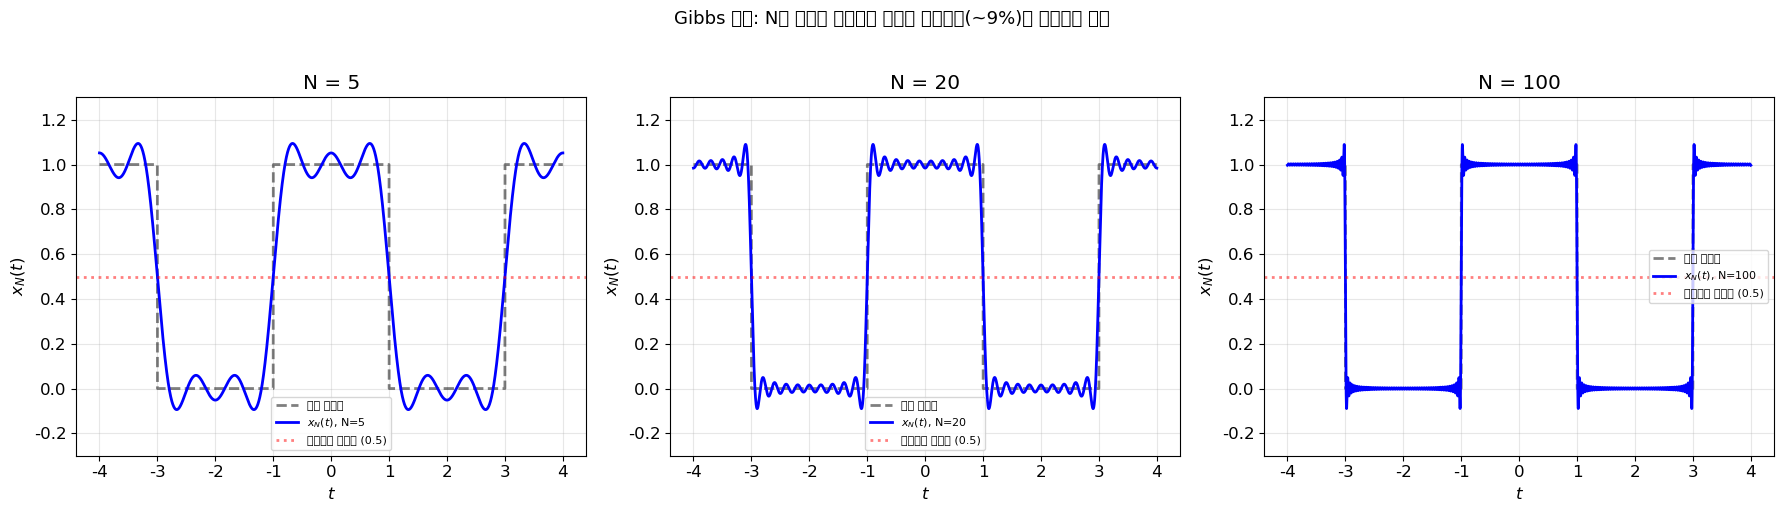

불연속점에서의 수렴값은 점프 높이의 중간값 = (0 + 1) / 2 = 0.5
N을 아무리 키워도 불연속점 근처의 ripple(Gibbs)은 완전히 사라지지 않습니다.


In [4]:
T = 4.0
T1 = T / 4
omega0 = 2 * np.pi / T
t = np.linspace(-T, T, 8000)

x_square = np.zeros_like(t)
t_mod = np.mod(t + T / 2, T) - T / 2
x_square[np.abs(t_mod) <= T1] = 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

N_values = [5, 20, 100]
for idx, N in enumerate(N_values):
    x_approx = (2 * T1 / T) * np.ones_like(t)
    for k in range(1, N + 1):
        ak = np.sin(k * omega0 * T1) / (k * np.pi)
        x_approx += 2 * ak * np.cos(k * omega0 * t)

    axes[idx].plot(t, x_square, 'k--', alpha=0.5, label='원래 사각파')
    axes[idx].plot(t, x_approx, 'b-', label=f'$x_{{N}}(t)$, N={N}')
    axes[idx].axhline(y=0.5, color='red', linestyle=':', alpha=0.5,
                      label='불연속점 수렴값 (0.5)')
    axes[idx].set_title(f'N = {N}')
    axes[idx].set_xlabel('$t$')
    axes[idx].set_ylabel('$x_N(t)$')
    axes[idx].set_ylim(-0.3, 1.3)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Gibbs 현상: N이 커져도 불연속점 근처의 오버슈트(~9%)는 사라지지 않음',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('불연속점에서의 수렴값은 점프 높이의 중간값 = (0 + 1) / 2 = 0.5')
print('N을 아무리 키워도 불연속점 근처의 ripple(Gibbs)은 완전히 사라지지 않습니다.')

---
## 3. STFT (Short-Time Fourier Transform)와 스펙트로그램

### 이론 배경

Fourier Series(또는 Fourier Transform)는 신호의 **전체적인** 주파수 구성을 알려주지만, **언제** 특정 주파수가 나타나는지는 알 수 없습니다.

**STFT(Short-Time Fourier Transform)** 는 이 문제를 해결합니다:

$$\text{STFT}\{x(t)\}(\tau, \omega) = \int_{-\infty}^{\infty} x(t) \, w(t - \tau) \, e^{-j\omega t} \, dt$$

- 신호에 **윈도우 함수** $w(t-\tau)$를 곱하여 짧은 구간의 신호를 잘라냄
- 각 구간에서 Fourier Transform을 적용
- 결과: 시간-주파수 평면에서의 에너지 분포 → **스펙트로그램**

> **스펙트로그램(Spectrogram):** STFT의 크기의 제곱, $|\text{STFT}(\tau, \omega)|^2$

이를 통해 시간에 따라 주파수 성분이 어떻게 변화하는지 시각적으로 확인할 수 있습니다.

### 예제 3-1: 주파수가 시간에 따라 변하는 신호 (Chirp Signal)

주파수가 선형적으로 증가하는 **chirp 신호**를 만들어 STFT와 스펙트로그램을 생성해 봅시다.

$$x(t) = \cos\left(2\pi \left(f_0 t + \frac{\beta}{2} t^2\right)\right)$$

여기서 순시 주파수는 $f(t) = f_0 + \beta t$ 로 시간에 따라 선형 증가합니다.

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: 

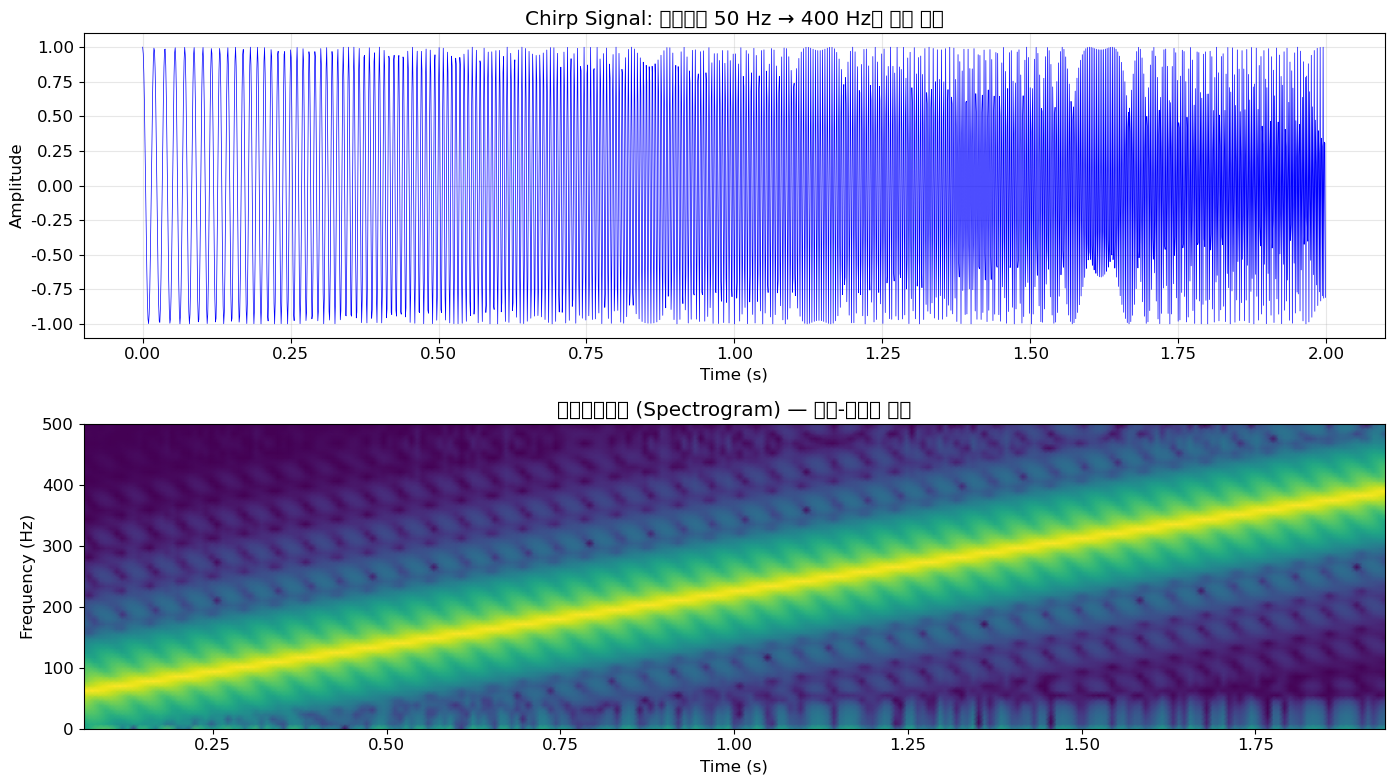

스펙트로그램에서 주파수가 시간에 따라 선형적으로 증가하는 모습을 확인할 수 있습니다.
이처럼 STFT를 이용하면 "언제 어떤 주파수가 존재하는지" 파악할 수 있습니다.


In [5]:
# 샘플링 설정
fs = 1000  # 샘플링 주파수 (Hz): 1초에 신호 값을 1000개 측정 -> 샘플 간격: 1/fs = 0.001초
duration = 2.0 # 신호 길이 2초
t = np.arange(0, duration, 1 / fs) # 신호 축을 만드는 코드 => 2000개

###===========================================================================
f0 = 50 # 시작 주파수:50Hz
f1 = 400 # 끝 주파수: 400Hz
beta = (f1 - f0) / duration # 주파수가 얼마나 빨리 증가하는지 나타내는 기울기
x_chirp = np.cos(2 * np.pi * (f0 * t + 0.5 * beta * t**2))
###===========================================================================
# 그래프
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(t, x_chirp, 'b-', linewidth=0.5)
axes[0].set_title('Chirp Signal: 주파수가 50 Hz → 400 Hz로 선형 증가')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
###===========================================================================
# Spectrogram 계산
f, t_spec, Sxx = spectrogram(x_chirp, fs=fs, nperseg=128, noverlap=120) # noverlap=120은 window 간 겹치는 부분이 120개 샘플(0.12초)이라는 의미
#  주파수 축, 시간 축, 각 시간-주파수 위치에서의 power 값 //128: widow 길이를 128개의 샘플로. fs=1000Hz이므로 128개의 샘플은 0.128초에 해당. noverlap=120은 window 간 겹치는 부분이 120개 샘플(0.12초)이라는 의미
axes[1].pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis') # power 는 값의 범위가 매우 클 수 있어서 로그 스케일인 dB로 표현
axes[1].set_title('스펙트로그램 (Spectrogram) — 시간-주파수 분석')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

print('스펙트로그램에서 주파수가 시간에 따라 선형적으로 증가하는 모습을 확인할 수 있습니다.')
print('이처럼 STFT를 이용하면 "언제 어떤 주파수가 존재하는지" 파악할 수 있습니다.')

### 예제 3-2: 여러 주파수 성분이 시간에 따라 바뀌는 신호

실생활의 신호는 시간에 따라 주파수 구성이 변합니다. 예를 들어, 음악이나 음성 신호가 그렇습니다.

아래에서는 세 개의 서로 다른 주파수가 **시간대별로 등장**하는 신호를 만들어 스펙트로그램으로 분석해 봅니다:

- $0 \leq t < 1$: $f = 100\,\text{Hz}$
- $1 \leq t < 2$: $f = 100\,\text{Hz}$ + $f = 250\,\text{Hz}$
- $2 \leq t < 3$: $f = 250\,\text{Hz}$ + $f = 400\,\text{Hz}$

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
C:\Users\yhcat\AppData\Local\Temp\ipykernel_4988\3140686380.py:42

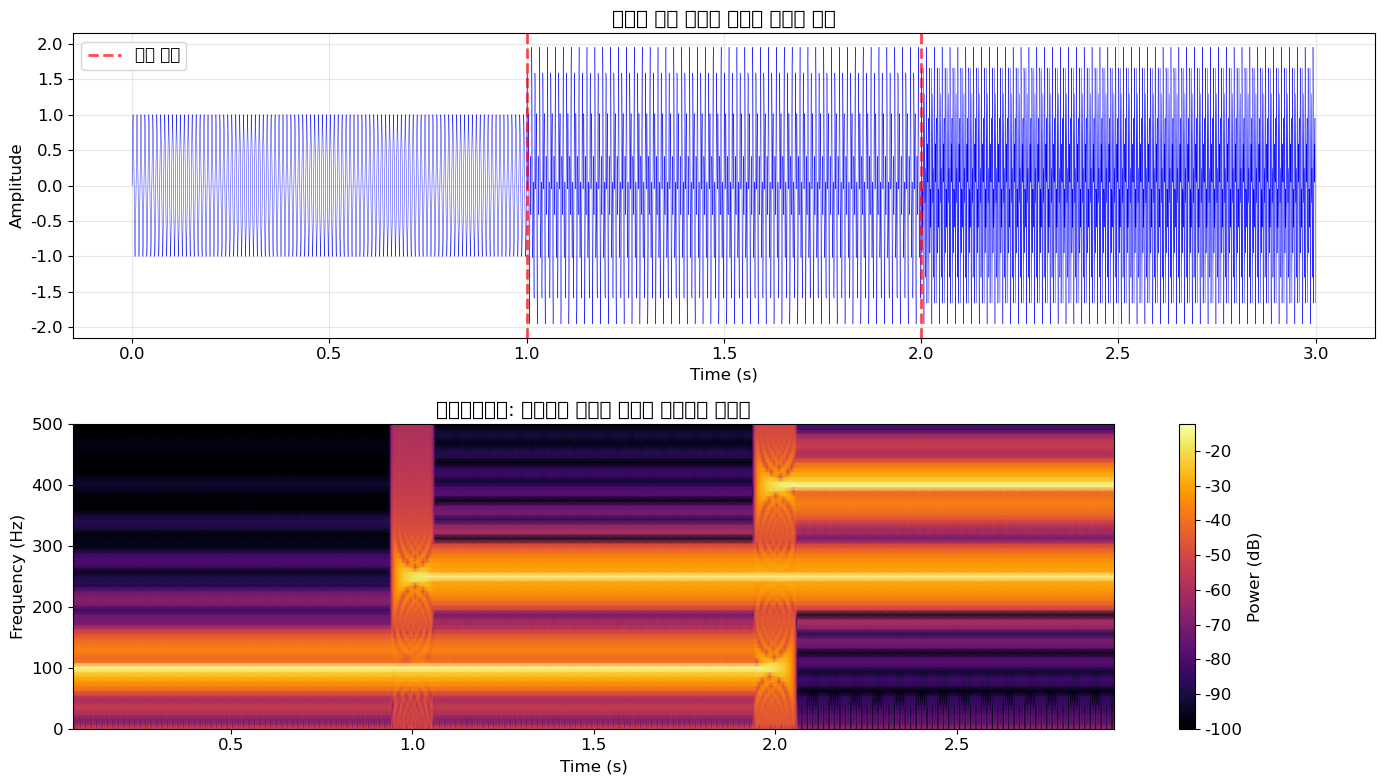

구간 1 (0~1s): 100 Hz만 존재
구간 2 (1~2s): 100 Hz + 250 Hz가 공존
구간 3 (2~3s): 250 Hz + 400 Hz가 공존

→ 일반 Fourier Transform으로는 "전체 시간"에 걸친 평균적인 주파수만 보입니다.
→ STFT(스펙트로그램)를 쓰면 "언제" 어떤 주파수가 나타나는지 분석할 수 있습니다!


In [6]:
fs = 2000 # 1초에 신호 200번 => 샘플 간격 -> 1/2000초 = 0.0005초
duration = 3.0 # 신호 전체 길이
t = np.arange(0, duration, 1 / fs) # 신호 축을 만드는 코드 => 6000개

x_multi = np.zeros_like(t) #  신호 배열을 0으로 초기화(이후 구간별로 원하는 sine 신호를 넣으려고)

mask1 = (t >= 0) & (t < 1) # 0~1: True
x_multi[mask1] = np.sin(2 * np.pi * 100 * t[mask1])

mask2 = (t >= 1) & (t < 2)
x_multi[mask2] = (np.sin(2 * np.pi * 100 * t[mask2])
                   + np.sin(2 * np.pi * 250 * t[mask2]))

mask3 = (t >= 2) & (t < 3)
x_multi[mask3] = (np.sin(2 * np.pi * 250 * t[mask3])
                   + np.sin(2 * np.pi * 400 * t[mask3]))
###===========================================================================
# 그래프 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(t, x_multi, 'b-', linewidth=0.3)
axes[0].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='구간 전환')
axes[0].axvline(x=2.0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('시간에 따라 주파수 구성이 변하는 신호')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
###===========================================================================
# Spectrogram 계산

f, t_spec, Sxx = spectrogram(x_multi, fs=fs, nperseg=256, noverlap=250)
# 256 samples per window -> 0.128초 단위로 주파수 분석, noverlap=250은 window 간 겹치는 부분이 250개 샘플(0.125초)이라는 의미
pcm = axes[1].pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10),
                          shading='gouraud', cmap='inferno')
axes[1].set_title('스펙트로그램: 시간대별 주파수 성분이 명확하게 구분됨')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim(0, 500)
plt.colorbar(pcm, ax=axes[1], label='Power (dB)')

plt.tight_layout()
plt.show()

print('구간 1 (0~1s): 100 Hz만 존재')
print('구간 2 (1~2s): 100 Hz + 250 Hz가 공존')
print('구간 3 (2~3s): 250 Hz + 400 Hz가 공존')
print()
print('→ 일반 Fourier Transform으로는 "전체 시간"에 걸친 평균적인 주파수만 보입니다.')
print('→ STFT(스펙트로그램)를 쓰면 "언제" 어떤 주파수가 나타나는지 분석할 수 있습니다!')

### 예제 3-3: AM 변조 신호의 스펙트로그램 분석

AM(Amplitude Modulation) 변조는 높은 주파수의 반송파(carrier)에 낮은 주파수의 정보 신호를 실어 보내는 방식입니다:

$$x(t) = [1 + m \cos(2\pi f_m t)] \cdot \cos(2\pi f_c t)$$

- $f_c$: 반송파(carrier) 주파수
- $f_m$: 변조(message) 신호의 주파수
- $m$: 변조 지수 (modulation index)

삼각함수 곱 공식에 의해, 스펙트로그램에서는 $f_c$, $f_c + f_m$, $f_c - f_m$ 세 주파수가 관찰됩니다.

반송파: 정보를 실어서 멀리 보내기 위한 높은 주파수 파형   
변조 신호(message/modulating signal): 실제로 전달하고 싶은 낮은 주파수 정보   
반송파: $\cos(2\pi f_c t)$ (높은 주파수: 500Hz)   
낮은 주파수 정보 신호를 그대로 보내기보다 높은 주파수 파형에 실어서 보내는 게 통신에 유리 

변조 신호: $\cos(2\pi f_m t)$ (낮은 주파수: 40Hz)  
AM 신호 = 천천히 변하는 진폭 * 빠르게 진동하는 반송파   
포락선(envelope): 빠르게 진동하는 파형의 바깥 윤곽선:   
$1 + m \cos(2\pi f_m t)$ 
m: 변조 지수: 반송파의 진폭을 얼마나 세게 흔들 것인가  

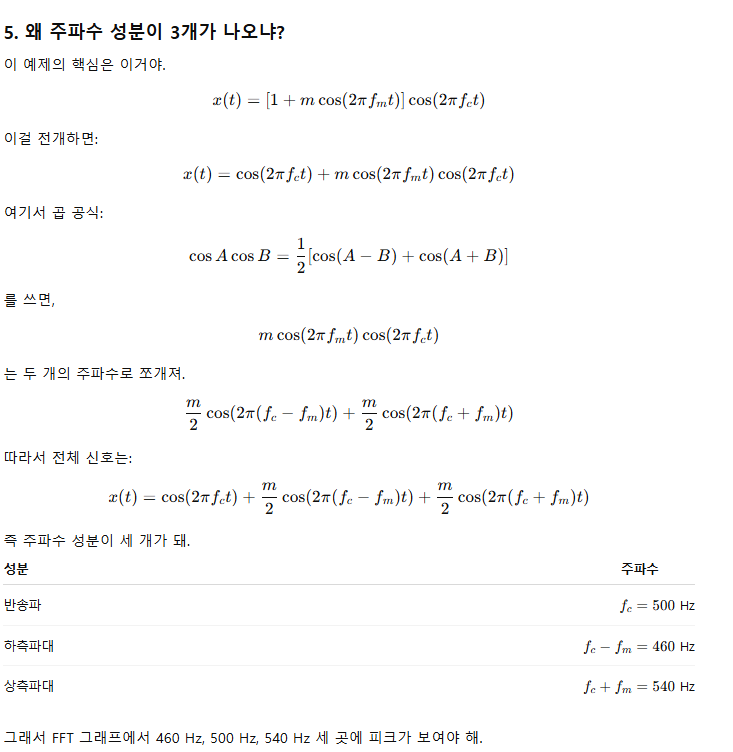

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
Font 'default' does not have a glyph for '\ubcc0' [U+bcc0], substituting with a dummy symbol.
Font 'default' does not ha

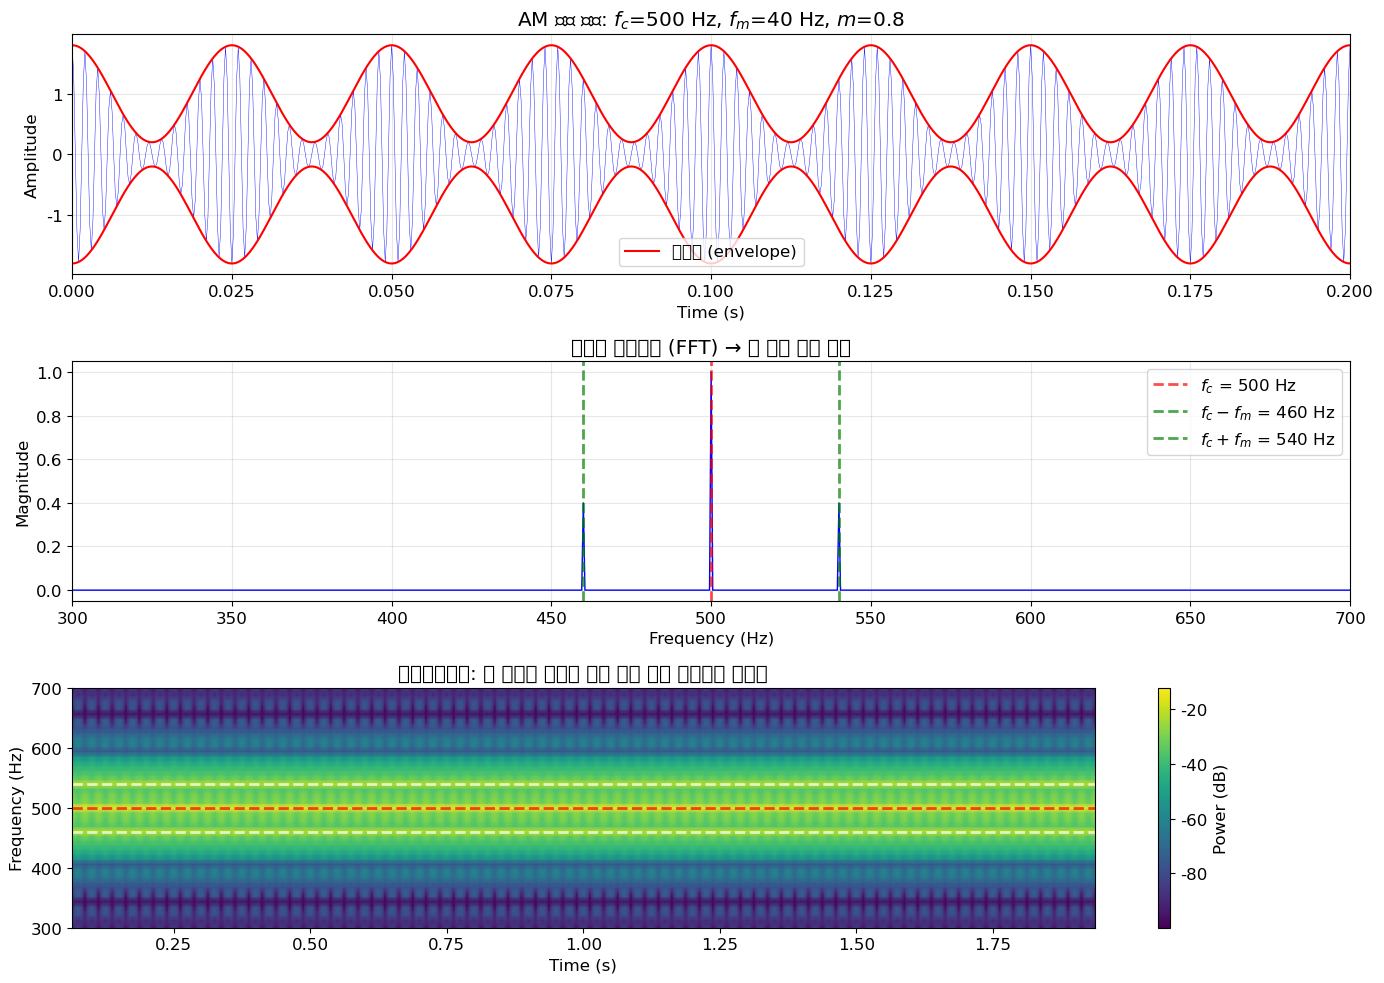

AM 변조 신호의 주파수 성분:
  반송파: f_c = 500 Hz
  하측파대: f_c - f_m = 460 Hz
  상측파대: f_c + f_m = 540 Hz

→ 곱 공식: cos(A)cos(B) = ½[cos(A-B) + cos(A+B)]
→ 하나의 곱셈이 주파수 영역에서는 세 개의 독립적인 성분으로 분해됩니다!


In [7]:
# 시간 영역에서 두 신호를 곱하면, 주파수 영역에서는 원래 주파수 주변에 새로운 주파수 성분이 생긴다.
fs = 4000
duration = 2.0
t = np.arange(0, duration, 1 / fs)
###=========================================================================
# AM 변조 신호 생성(반송파 fc=500Hz, 변조 신호 fm=40Hz, 변조 지수 m=0.8)
fc = 500
fm = 40
m = 0.8 # 반송파의 진폭이 변조 신호의 진폭에 따라 80%까지 변하는 AM 신호 생성 ->0.2에서 1.8 사이를 움직임
x_am = (1 + m * np.cos(2 * np.pi * fm * t)) * np.cos(2 * np.pi * fc * t)
###========================================================================
# 그래프 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(t, x_am, 'b-', linewidth=0.3)
envelope = 1 + m * np.cos(2 * np.pi * fm * t)
axes[0].plot(t, envelope, 'r-', linewidth=1.5, label='포락선 (envelope)')
axes[0].plot(t, -envelope, 'r-', linewidth=1.5)
axes[0].set_title(f'AM 변조 신호: $f_c$={fc} Hz, $f_m$={fm} Hz, $m$={m}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlim(0, 0.2)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
###===========================================================================  
# FFT 계산 및 주파수 스펙트럼 시각화
# 전체 신호를 FFT해서, 전체 주파수 성분을 봄
N = len(t)
X = np.fft.rfft(x_am)
freqs = np.fft.rfftfreq(N, d=1/fs)
magnitude = 2 * np.abs(X) / N

axes[1].plot(freqs, magnitude, 'b-', linewidth=1)
axes[1].set_title('주파수 스펙트럼 (FFT) → 세 개의 피크 확인')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].set_xlim(300, 700)
axes[1].axvline(x=fc, color='red', linestyle='--', alpha=0.7, label=f'$f_c$ = {fc} Hz')
axes[1].axvline(x=fc-fm, color='green', linestyle='--', alpha=0.7, label=f'$f_c - f_m$ = {fc-fm} Hz')
axes[1].axvline(x=fc+fm, color='green', linestyle='--', alpha=0.7, label=f'$f_c + f_m$ = {fc+fm} Hz')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

f_s, t_s, Sxx_s = spectrogram(x_am, fs=fs, nperseg=512, noverlap=500)
pcm = axes[2].pcolormesh(t_s, f_s, 10 * np.log10(Sxx_s + 1e-10),
                          shading='gouraud', cmap='viridis')
axes[2].set_title('스펙트로그램: 세 주파수 성분이 시간 축을 따라 일정하게 유지됨')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_ylim(300, 700)
axes[2].axhline(y=fc, color='red', linestyle='--', alpha=0.7)
axes[2].axhline(y=fc-fm, color='white', linestyle='--', alpha=0.7)
axes[2].axhline(y=fc+fm, color='white', linestyle='--', alpha=0.7)
plt.colorbar(pcm, ax=axes[2], label='Power (dB)')

plt.tight_layout()
plt.show()

print(f'AM 변조 신호의 주파수 성분:')
print(f'  반송파: f_c = {fc} Hz')
print(f'  하측파대: f_c - f_m = {fc - fm} Hz')
print(f'  상측파대: f_c + f_m = {fc + fm} Hz')
print()
print('→ 곱 공식: cos(A)cos(B) = ½[cos(A-B) + cos(A+B)]')
print('→ 하나의 곱셈이 주파수 영역에서는 세 개의 독립적인 성분으로 분해됩니다!')

### 예제 3-4: 윈도우 크기에 따른 시간–주파수 해상도 트레이드오프

STFT에서 윈도우 크기를 바꾸면 시간 해상도와 주파수 해상도 사이에 **트레이드오프**가 존재합니다:

- **윈도우가 길면 (큰 window_size):** 주파수 해상도 ↑, 시간 해상도 ↓
- **윈도우가 짧으면 (작은 window_size):** 시간 해상도 ↑, 주파수 해상도 ↓

이는 **불확정성 원리 (Uncertainty Principle)** 와 관련됩니다.

짧게 자르면 → 언제 바뀌는지는 잘 보임, 주파수는 흐릿함   
길게 자르면 → 주파수는 정확히 보임, 언제 바뀌는지는 흐릿함

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
C:\Users\yhcat\AppData\Local\Temp\ipykernel_4988\3923836439.py:33

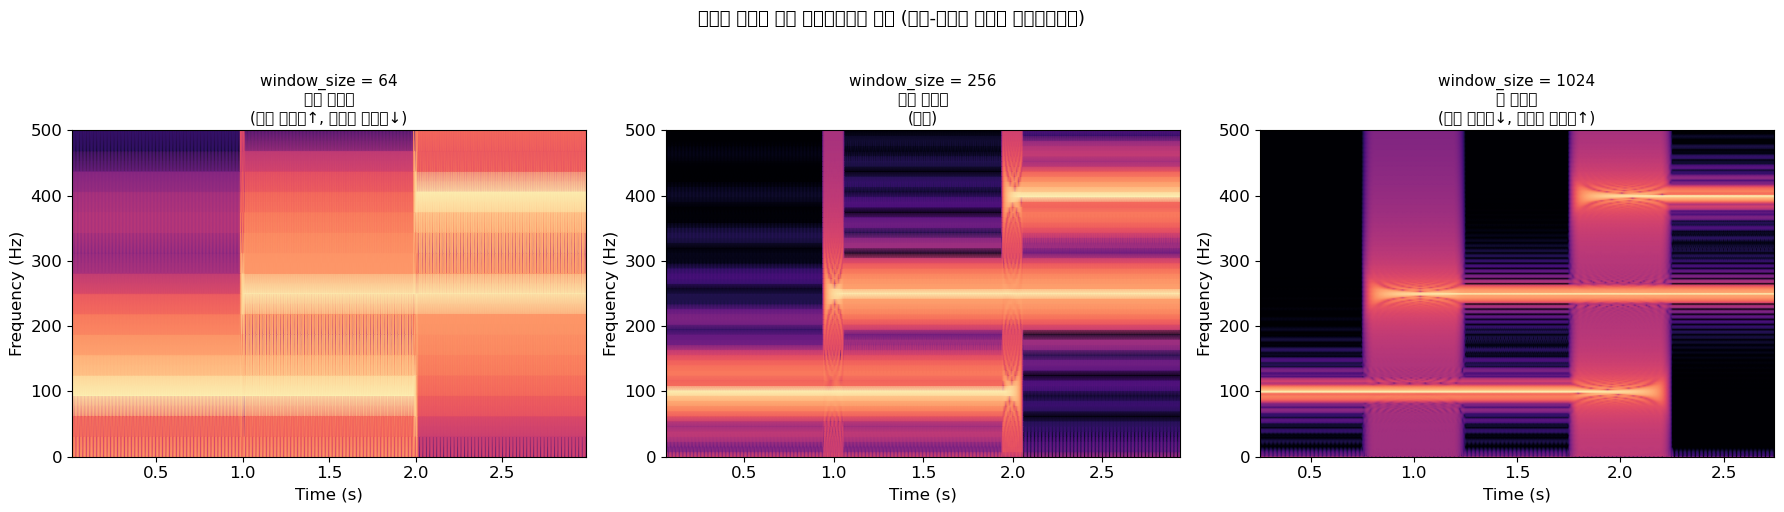

윈도우가 짧을수록 → 시간 변화를 잘 포착하지만, 주파수가 뭉개짐
윈도우가 길수록 → 주파수를 정밀하게 구분하지만, 시간 변화가 뭉개짐

이 트레이드오프는 피할 수 없으며, 분석 목적에 맞게 윈도우 크기를 선택해야 합니다.


In [8]:
# 예제 3-2 신호
fs_test = 2000
duration_test = 3.0
t_test = np.arange(0, duration_test, 1 / fs_test)

x_test = np.zeros_like(t_test)
x_test[(t_test >= 0) & (t_test < 1)] = np.sin(2 * np.pi * 100 * t_test[(t_test >= 0) & (t_test < 1)])
x_test[(t_test >= 1) & (t_test < 2)] = (np.sin(2 * np.pi * 100 * t_test[(t_test >= 1) & (t_test < 2)])
                                          + np.sin(2 * np.pi * 250 * t_test[(t_test >= 1) & (t_test < 2)]))
x_test[(t_test >= 2) & (t_test < 3)] = (np.sin(2 * np.pi * 250 * t_test[(t_test >= 2) & (t_test < 3)])
                                          + np.sin(2 * np.pi * 400 * t_test[(t_test >= 2) & (t_test < 3)]))
###===========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# window 크기를 바꿔서 비교
window_sizes = [64, 256, 1024]
titles = ['짧은 윈도우\n(시간 해상도↑, 주파수 해상도↓)',
          '중간 윈도우\n(균형)',
          '긴 윈도우\n(시간 해상도↓, 주파수 해상도↑)']

for idx, ws in enumerate(window_sizes):
    overlap = ws - 8
    f_s, t_s, Sxx_s = spectrogram(x_test, fs=fs_test, nperseg=ws,
                                   noverlap=max(0, overlap))
    pcm = axes[idx].pcolormesh(t_s, f_s, 10 * np.log10(Sxx_s + 1e-10),
                               shading='gouraud', cmap='magma')
    axes[idx].set_title(f'window_size = {ws}\n{titles[idx]}', fontsize=11)
    axes[idx].set_xlabel('Time (s)')
    axes[idx].set_ylabel('Frequency (Hz)')
    axes[idx].set_ylim(0, 500)

plt.suptitle('윈도우 크기에 따른 스펙트로그램 비교 (시간-주파수 해상도 트레이드오프)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('윈도우가 짧을수록 → 시간 변화를 잘 포착하지만, 주파수가 뭉개짐')
print('윈도우가 길수록 → 주파수를 정밀하게 구분하지만, 시간 변화가 뭉개짐')
print()
print('이 트레이드오프는 피할 수 없으며, 분석 목적에 맞게 윈도우 크기를 선택해야 합니다.')

### 예제 3-5: 실제 음성 신호 (LibriSpeech) 분석

지금까지 인공적으로 생성한 신호를 분석했습니다. 이번에는 **실제 사람의 음성**을 직접 들어보고, 스펙트로그램으로 분석해 봅시다.

`librosa` 라이브러리에 내장된 **LibriSpeech** 데이터셋 샘플을 사용합니다.

> LibriSpeech는 약 1,000시간 분량의 영어 음성 데이터셋으로, 음성 인식 연구에 널리 사용됩니다.

In [9]:
from IPython.display import Audio, display

y_speech, sr_speech = librosa.load(librosa.example('libri1'), sr=None)

transcript = ("He hoped there would be stew for dinner, turnips and carrots "
              "and bruised potatoes and fat mutton pieces to be ladled out "
              "in thick peppered flour-fattened sauce.")

print(f'샘플링 레이트: {sr_speech} Hz')
print(f'신호 길이: {len(y_speech)/sr_speech:.2f}초')
print(f'총 샘플 수: {len(y_speech):,}개')
print()
print(f'전사문 (Transcript):')
print(f'  "{transcript}"')
print(f'  — James Joyce, "A Portrait of the Artist as a Young Man"')
print()
print('▶ 아래 플레이어로 음성을 들어보세요:')
display(Audio(y_speech, rate=sr_speech))

샘플링 레이트: 22050 Hz
신호 길이: 14.84초
총 샘플 수: 327,222개

전사문 (Transcript):
  "He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick peppered flour-fattened sauce."
  — James Joyce, "A Portrait of the Artist as a Young Man"

▶ 아래 플레이어로 음성을 들어보세요:


STFT Short term FT

RMS 작음 → 묵음  
RMS 충분히 큼 + ZCR 큼 → 무성음  
RMS 충분히 큼 + ZCR 작음 → 유성음  

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
C:\Users\yhcat\AppData\Local\Temp\ipykernel_4988\3469346050.py:70: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yhcat\AppData\Local\Temp\ipykernel_4988\34693460

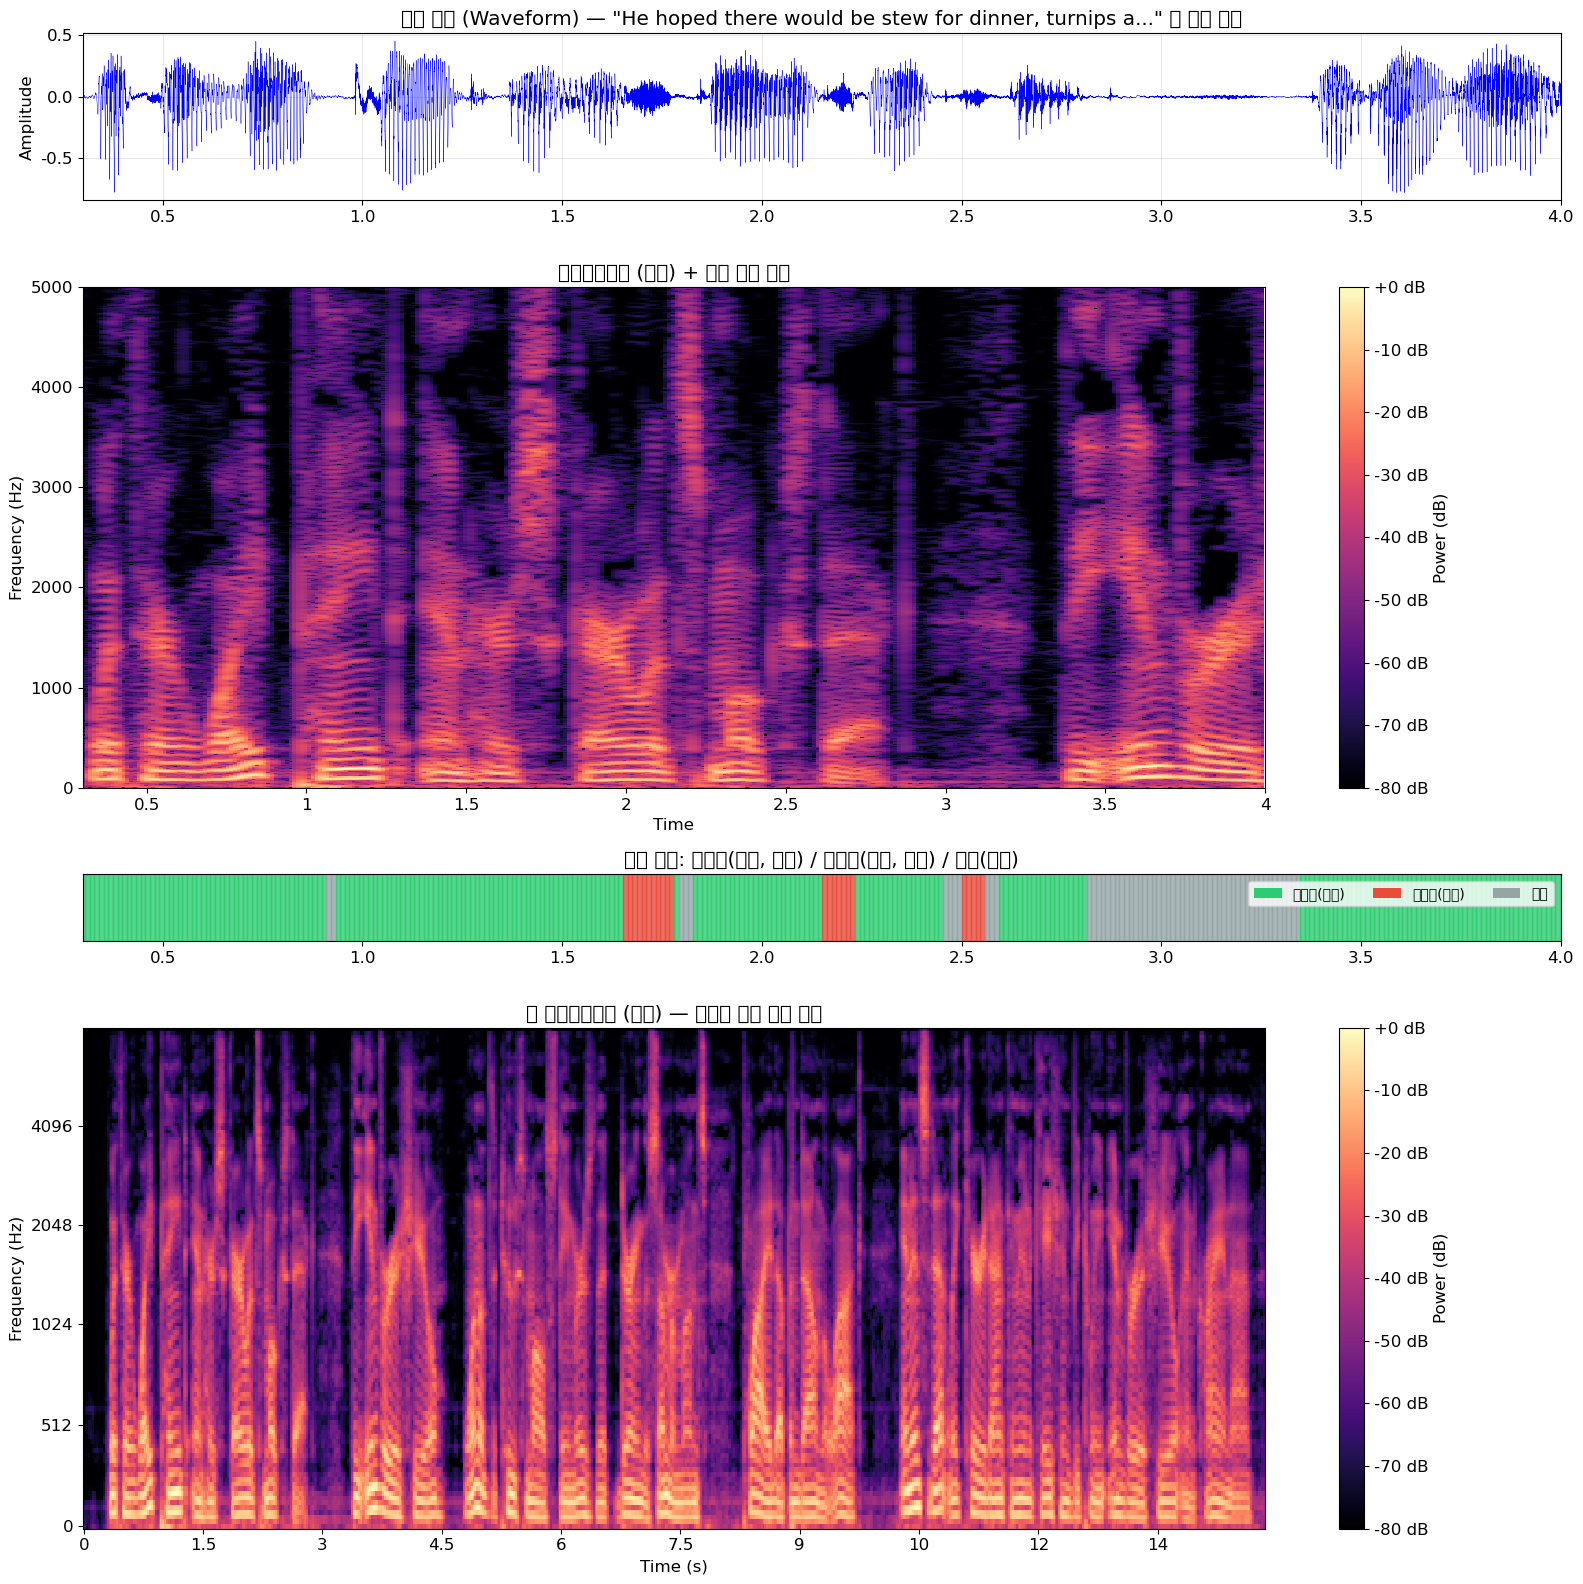

스펙트로그램 읽는 법:

  [초록 = 유성음/모음 구간]
    → 뚜렷한 가로줄 여러 개가 보임 (= 포먼트, Formant)
    → 성대가 진동하면서 기본 주파수의 정수배(고조파)가 생기기 때문
    → 예: "He", "hoped", "would", "stew" 등의 모음 부분

  [빨강 = 무성음/자음 구간]
    → 넓은 주파수 대역에 고르게 에너지가 분포 (= 잡음 형태)
    → 성대 진동 없이 공기 마찰로 소리를 냄
    → 예: "s", "t", "th", "f" 등의 자음

  [회색 = 묵음 구간]
    → 에너지가 거의 없는 어두운 영역
    → 단어 사이의 짧은 쉼이나 파열음("p", "t", "k") 직전의 폐쇄 구간


In [10]:
from matplotlib.patches import Patch

seg_start, seg_end = 0.3, 4.0 # 전체 음성 중 0.3~0.4초 구간만 잘라서 본다.(길고 복잡하니까)
y_seg = y_speech[int(sr_speech * seg_start):int(sr_speech * seg_end)] # 잘라낸 음성 신호
t_seg = np.arange(len(y_seg)) / sr_speech + seg_start # 대응되는 시간축

hop = 256
rms = librosa.feature.rms(y=y_seg, hop_length=hop)[0] # 소리의 크기 => 묵음인지 아닌지를 판단
zcr = librosa.feature.zero_crossing_rate(y=y_seg, hop_length=hop)[0] # 신호가 0을 몇 번 넘는지 => 유성음인지 무성음인지 판단
t_feat = librosa.times_like(rms, sr=sr_speech, hop_length=hop) + seg_start

rms_thresh = np.max(rms) * 0.08  # 임계값 설정
zcr_thresh = 0.12

labels = []
for r, z in zip(rms, zcr):
    if r < rms_thresh:
        labels.append('silence')
    elif z > zcr_thresh:
        labels.append('unvoiced')
    else:
        labels.append('voiced')

fig, axes = plt.subplots(4, 1, figsize=(16, 16),
                          gridspec_kw={'height_ratios': [1, 3, 0.4, 3]})

axes[0].plot(t_seg, y_seg, 'b-', linewidth=0.3)
axes[0].set_title(f'음성 파형 (Waveform) — "{transcript[:50]}..." 의 처음 부분')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlim(seg_start, seg_end)
axes[0].grid(True, alpha=0.3)

D = librosa.stft(y_seg, n_fft=2048, hop_length=hop) # 복소수 STFT 계수를 구함
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max) # abs: 계수의 크기만 구함., dB 단위로 변환
img1 = librosa.display.specshow(S_db, x_axis='time', y_axis='hz',
                                 sr=sr_speech, hop_length=hop,
                                 ax=axes[1], cmap='magma',
                                 x_coords=t_feat)
axes[1].set_title('스펙트로그램 (확대) + 음성 특성 구분')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim(0, 5000)
axes[1].set_xlim(seg_start, seg_end)
fig.colorbar(img1, ax=axes[1], format='%+2.0f dB', label='Power (dB)')

color_map = {'voiced': '#2ecc71', 'unvoiced': '#e74c3c', 'silence': '#95a5a6'}
label_map = {'voiced': '유성음(모음)', 'unvoiced': '무성음(자음)', 'silence': '묵음'}
dt = t_feat[1] - t_feat[0] if len(t_feat) > 1 else hop / sr_speech
for i, lab in enumerate(labels):
    axes[2].axvspan(t_feat[i] - dt/2, t_feat[i] + dt/2,
                     color=color_map[lab], alpha=0.8)
axes[2].set_xlim(seg_start, seg_end)
axes[2].set_yticks([])
axes[2].set_title('자동 탐지: 유성음(모음, 초록) / 무성음(자음, 빨강) / 묵음(회색)')
legend_handles = [Patch(facecolor=color_map[k], label=label_map[k])
                  for k in ['voiced', 'unvoiced', 'silence']]
axes[2].legend(handles=legend_handles, loc='upper right', ncol=3, fontsize=10)
###===========================================================================
# 사람의 귀가 느끼는 방식에 더 가깝게 주파수 축을 변환
# 사람은 낮은 주파수 차이에 더 민감하고 높은 주파수 차이는 상대적으로 둔감하다.
S_full = librosa.feature.melspectrogram(y=y_speech, sr=sr_speech,
                                         n_mels=128, fmax=8000)
S_full_dB = librosa.power_to_db(S_full, ref=np.max)
img2 = librosa.display.specshow(S_full_dB, x_axis='time', y_axis='mel',
                                 sr=sr_speech, fmax=8000, ax=axes[3], cmap='magma')
axes[3].set_title('멜 스펙트로그램 (전체) — 사람의 청각 특성 반영')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Frequency (Hz)')
fig.colorbar(img2, ax=axes[3], format='%+2.0f dB', label='Power (dB)')

plt.tight_layout()
plt.show()

print('스펙트로그램 읽는 법:')
print()
print('  [초록 = 유성음/모음 구간]')
print('    → 뚜렷한 가로줄 여러 개가 보임 (= 포먼트, Formant)')
print('    → 성대가 진동하면서 기본 주파수의 정수배(고조파)가 생기기 때문')
print('    → 예: "He", "hoped", "would", "stew" 등의 모음 부분')
print()
print('  [빨강 = 무성음/자음 구간]')
print('    → 넓은 주파수 대역에 고르게 에너지가 분포 (= 잡음 형태)')
print('    → 성대 진동 없이 공기 마찰로 소리를 냄')
print('    → 예: "s", "t", "th", "f" 등의 자음')
print()
print('  [회색 = 묵음 구간]')
print('    → 에너지가 거의 없는 어두운 영역')
print('    → 단어 사이의 짧은 쉼이나 파열음("p", "t", "k") 직전의 폐쇄 구간')

---
## 4. 종합 예제: 주파수별 분해와 스펙트로그램을 함께 활용

아래 예제에서는 여러 고조파 성분으로 구성된 주기 신호를 **주파수별로 분해**한 뒤, 이 각각의 성분을 **STFT/스펙트로그램**으로 확인해 봅니다.

이 과정은 수업에서 배운 **Fourier Series**의 핵심 아이디어와 정확히 일치합니다:

> "입력을 주파수 별로 분리할 수 있으면, 각각에 대한 출력을 구하여 전체 출력은 이들의 합으로 나타낼 수 있다."

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: 

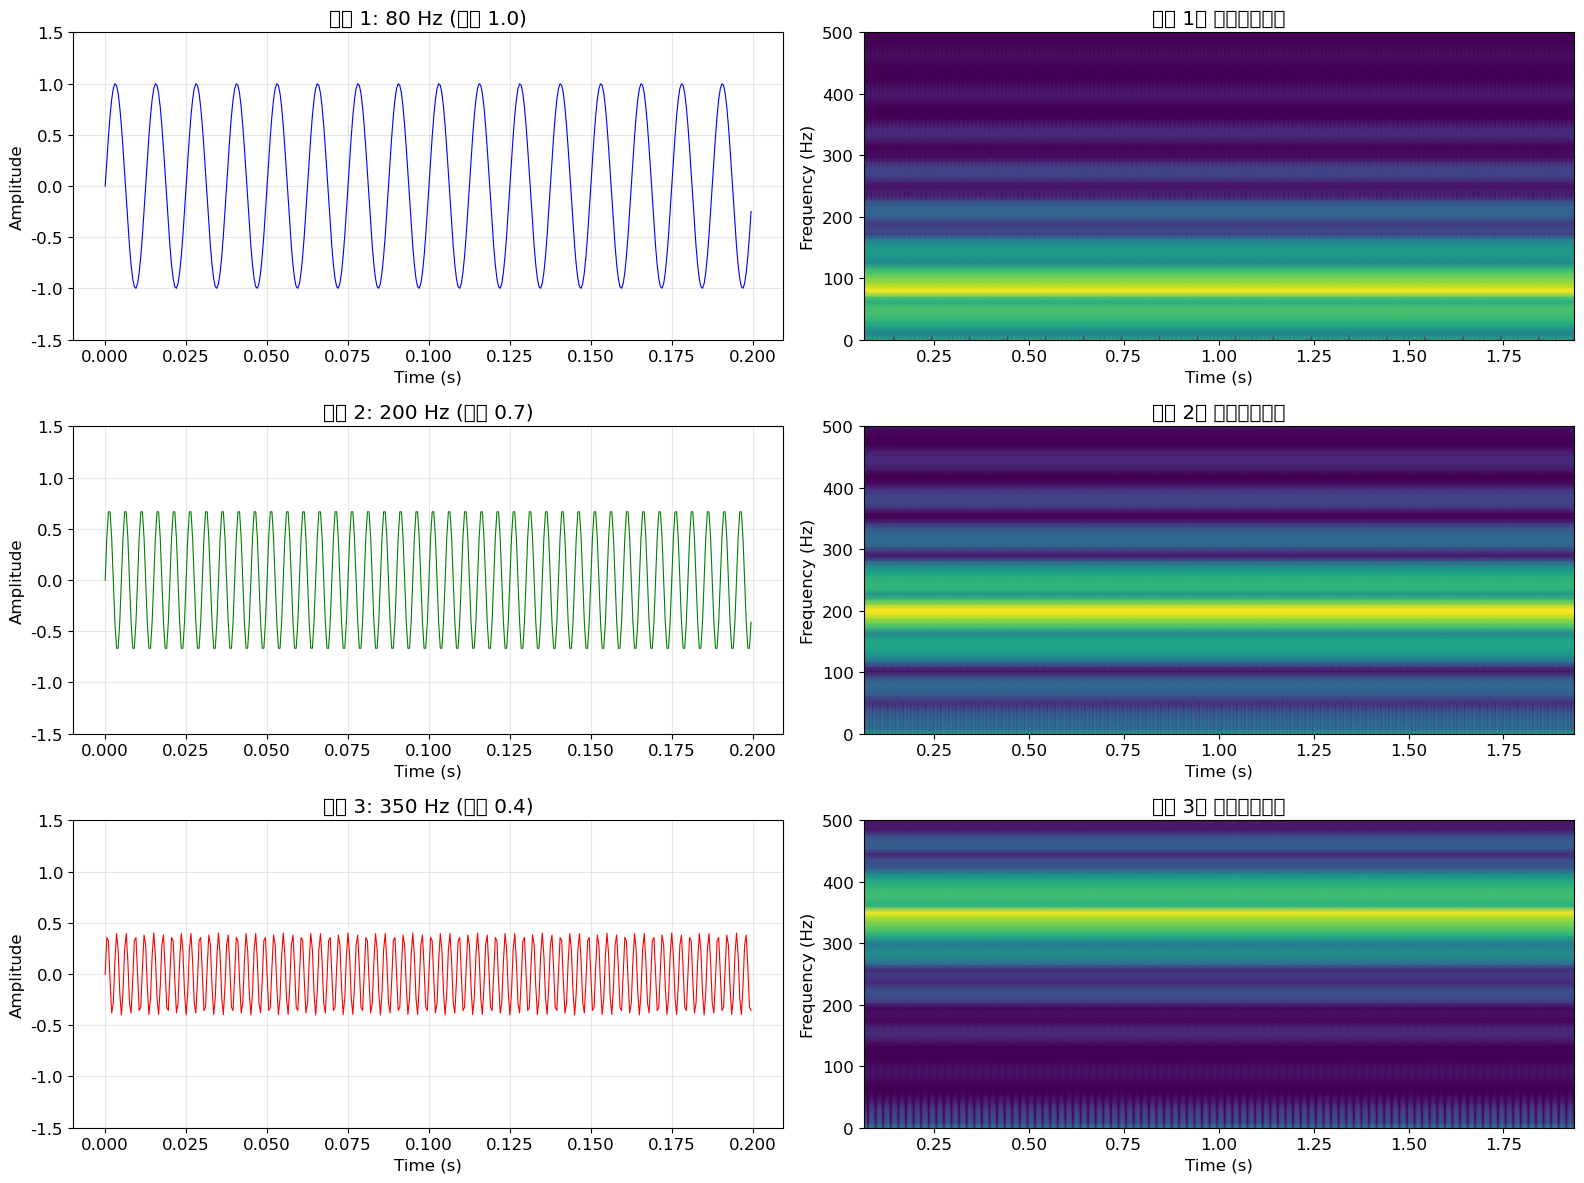

findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: 

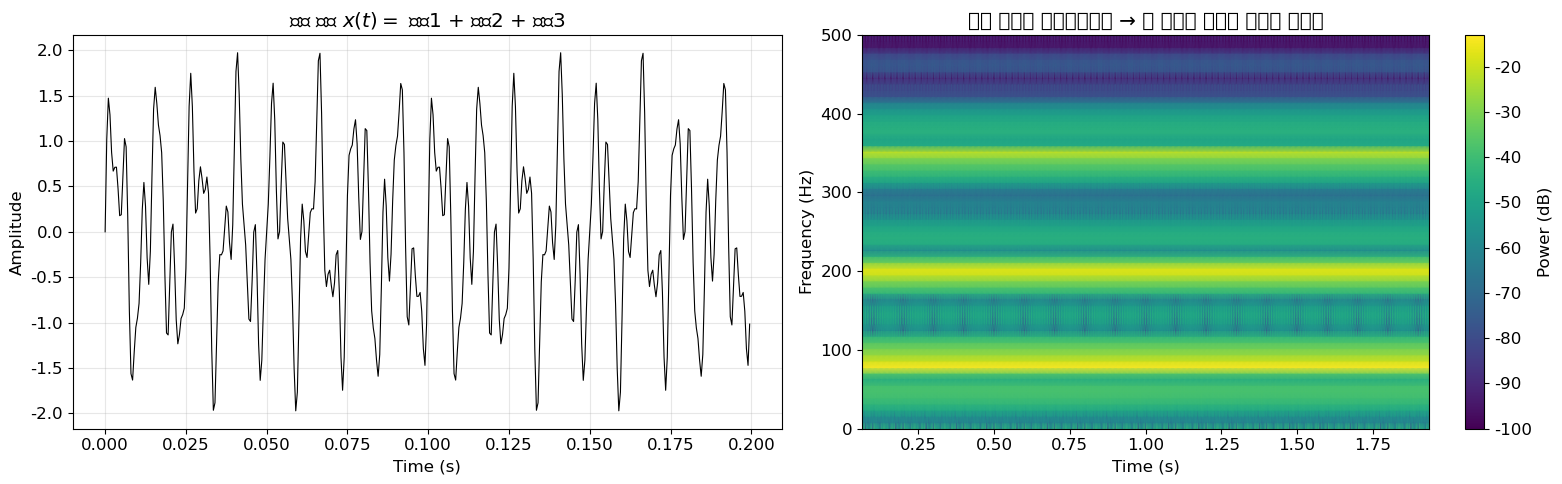

합성 신호는 시간 영역에서 복잡해 보이지만,
스펙트로그램에서는 세 개의 주파수 성분(80, 200, 350 Hz)이 명확하게 분리됩니다.

이것이 바로 Fourier Series의 핵심 아이디어입니다:
→ 복잡한 신호를 주파수별 고조파 성분으로 분해하여 분석할 수 있다!


In [11]:
fs = 2000
duration = 2.0
t = np.arange(0, duration, 1 / fs)

f1, f2, f3 = 80, 200, 350
component1 = 1.0 * np.sin(2 * np.pi * f1 * t)
component2 = 0.7 * np.sin(2 * np.pi * f2 * t)
component3 = 0.4 * np.sin(2 * np.pi * f3 * t)
x_total = component1 + component2 + component3

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

signals = [component1, component2, component3]
labels = [f'{f1} Hz (진폭 1.0)', f'{f2} Hz (진폭 0.7)', f'{f3} Hz (진폭 0.4)']
colors_list = ['blue', 'green', 'red']

for i in range(3):
    axes[i, 0].plot(t[:400], signals[i][:400], color=colors_list[i], linewidth=0.8)
    axes[i, 0].set_title(f'성분 {i+1}: {labels[i]}')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].set_ylim(-1.5, 1.5)

    f_s, t_s, Sxx_s = spectrogram(signals[i], fs=fs, nperseg=256, noverlap=248)
    axes[i, 1].pcolormesh(t_s, f_s, 10 * np.log10(Sxx_s + 1e-10),
                           shading='gouraud', cmap='viridis')
    axes[i, 1].set_title(f'성분 {i+1}의 스펙트로그램')
    axes[i, 1].set_xlabel('Time (s)')
    axes[i, 1].set_ylabel('Frequency (Hz)')
    axes[i, 1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(t[:400], x_total[:400], 'k-', linewidth=0.8)
axes[0].set_title('합성 신호 $x(t) = $ 성분1 + 성분2 + 성분3')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

f_s, t_s, Sxx_s = spectrogram(x_total, fs=fs, nperseg=256, noverlap=248)
pcm = axes[1].pcolormesh(t_s, f_s, 10 * np.log10(Sxx_s + 1e-10),
                          shading='gouraud', cmap='viridis')
axes[1].set_title('합성 신호의 스펙트로그램 → 세 주파수 성분이 명확히 분리됨')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim(0, 500)
plt.colorbar(pcm, ax=axes[1], label='Power (dB)')

plt.tight_layout()
plt.show()

print('합성 신호는 시간 영역에서 복잡해 보이지만,')
print('스펙트로그램에서는 세 개의 주파수 성분(80, 200, 350 Hz)이 명확하게 분리됩니다.')
print()
print('이것이 바로 Fourier Series의 핵심 아이디어입니다:')
print('→ 복잡한 신호를 주파수별 고조파 성분으로 분해하여 분석할 수 있다!')

---
## 정리

이번 실습에서 다룬 핵심 내용을 정리합니다:

| 주제 | 핵심 내용 |
|------|--------|
| **Fourier Series** | 주기 신호를 $a_k e^{jk\omega_0 t}$ 형태의 고조파 합으로 분해 |
| **주파수별 분해** | 각 고조파 성분을 개별적으로 분석 → LTI 시스템 출력을 쉽게 계산 |
| **Gibbs 현상** | 불연속점 근처에서 Fourier 근사의 오버슈트(~9%)가 항상 존재 |
| **STFT** | 윈도우 함수로 신호를 잘라 구간별 Fourier Transform 수행 |
| **스펙트로그램** | $|\text{STFT}|^2$ — 시간-주파수 평면에서 에너지 분포 시각화 |
| **시간-주파수 트레이드오프** | 윈도우가 길면 주파수 해상도↑/시간 해상도↓, 짧으면 반대 |

### 핵심 메시지

> Fourier Series를 통해 신호를 **주파수별로 분해**하면, 각 성분에 대한 시스템의 응답을 독립적으로 구할 수 있습니다.  
> STFT와 스펙트로그램은 이러한 주파수 분석을 **시간 축**까지 확장하여, 시간에 따라 변하는 주파수 구성을 분석할 수 있게 해 줍니다.